# Optimal ADI Weighting: Predicting IMD Rank

Can the ADI's three domains (employment, crime, health) predict the IMD's
overall deprivation rank? We fit a linear regression from all 39 ADI rate
columns to the IMD 2025 rank and examine which features contribute most.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

repo_root = Path.cwd()
if repo_root.name in ("analysis", "nbs", "pts"):
    repo_root = repo_root.parent
while not (repo_root / "config").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

imd_dir = repo_root / "store" / "inputs" / "imd"
adi_dir = repo_root / "store" / "outputs" / "default" / "lsoa"

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

## Load and merge data

In [ ]:
imd = pd.read_csv(imd_dir / "imd_2025.csv")
imd = imd.rename(columns={
    "LSOA code (2021)": "LSOA21CD",
    "Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)": "imd_rank",
})

cc = pd.read_csv(adi_dir / "claimant_counts" / "claimant_counts_2024.csv")
cr = pd.read_csv(adi_dir / "crime" / "crime_2024.csv")
health_files = sorted((adi_dir / "health").glob("health_*_24.csv")) + sorted((adi_dir / "health").glob("health_2024_*.csv"))
h = pd.read_csv(health_files[0]) if health_files else None

# Build feature matrix
features = cc[["LSOA21CD", "claimant_count_rate"]].rename(columns={"claimant_count_rate": "claimant_rate"})
crime_rate_cols = [c for c in cr.columns if c.endswith("_rate")]
features = features.merge(cr[["LSOA21CD"] + crime_rate_cols], on="LSOA21CD", how="inner")
if h is not None:
    health_rate_cols = [c for c in h.columns if c.endswith("_afflicted_rate")]
    features = features.merge(h[["LSOA21CD"] + health_rate_cols], on="LSOA21CD", how="inner")

df = features.merge(imd[["LSOA21CD", "imd_rank"]], on="LSOA21CD", how="inner")
feature_cols = [c for c in df.columns if c not in ("LSOA21CD", "LSOA21NM", "imd_rank")]
print(f"Dataset: {len(df)} LSOAs, {len(feature_cols)} features")

Dataset: 33749 LSOAs, 39 features


## Linear regression

In [ ]:
X = df[feature_cols].fillna(0).values
y = df["imd_rank"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reg = LinearRegression()
reg.fit(X_scaled, y)
y_pred = reg.predict(X_scaled)

r2 = reg.score(X_scaled, y)
r_spearman = stats.spearmanr(y, y_pred).statistic
print(f"R^2 = {r2:.4f}")
print(f"Spearman r = {r_spearman:.4f}")

R^2 = 0.6963
Spearman r = 0.8799


## Feature importance

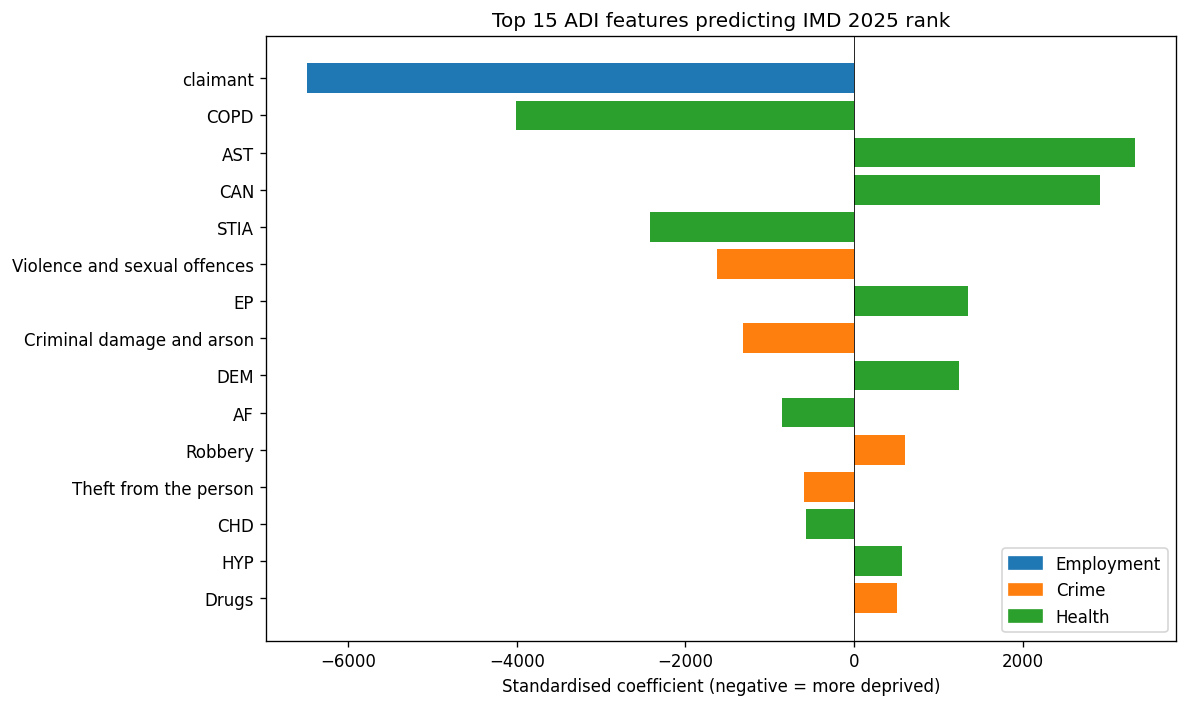

In [ ]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": reg.coef_,
    "abs_coef": np.abs(reg.coef_),
}).sort_values("abs_coef", ascending=False)

# Assign domain
def domain_of(c):
    if "claimant" in c: return "Employment"
    if "afflicted" in c: return "Health"
    return "Crime"

coef_df["domain"] = coef_df["feature"].apply(domain_of)
domain_colors = {"Employment": "tab:blue", "Crime": "tab:orange", "Health": "tab:green"}

# Plot top 15
top = coef_df.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top)), top["coefficient"].values, color=[domain_colors[d] for d in top["domain"]])
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f.replace("_afflicted_rate", "").replace("_rate", "") for f in top["feature"]])
ax.invert_yaxis()
ax.set_xlabel("Standardised coefficient (negative = more deprived)")
ax.set_title("Top 15 ADI features predicting IMD 2025 rank")
ax.axvline(0, color="black", linewidth=0.5)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=l) for l, c in domain_colors.items()], loc="lower right")
fig.tight_layout()
plt.savefig(repo_root / "store" / "outputs" / "adi_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Domain contribution

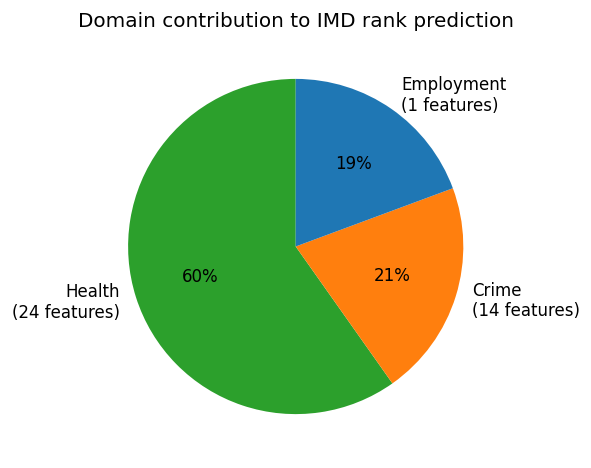

Domain contribution:
  Health         :  59.8%  (24 features)
  Crime          :  20.9%  (14 features)
  Employment     :  19.3%  (1 features)


In [ ]:
domain_imp = coef_df.groupby("domain")["abs_coef"].sum()
domain_imp_pct = (domain_imp / domain_imp.sum() * 100).sort_values(ascending=False)
domain_counts = coef_df.groupby("domain").size()

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie(domain_imp_pct.values, labels=[f"{d}\n({domain_counts[d]} features)" for d in domain_imp_pct.index],
       colors=[domain_colors[d] for d in domain_imp_pct.index],
       autopct="%1.0f%%", startangle=90)
ax.set_title("Domain contribution to IMD rank prediction")
fig.tight_layout()
plt.savefig(repo_root / "store" / "outputs" / "adi_domain_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Domain contribution:")
for d in domain_imp_pct.index:
    print(f"  {d:15s}: {domain_imp_pct[d]:5.1f}%  ({domain_counts[d]} features)")

## Model comparison

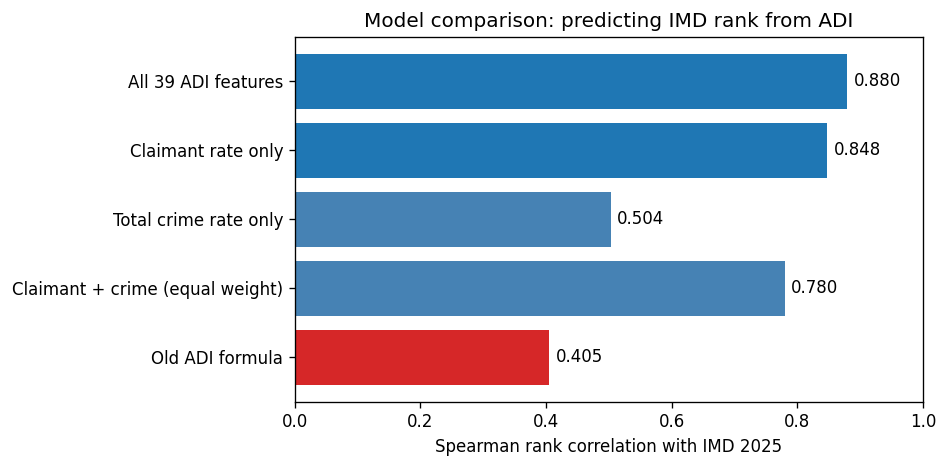

In [ ]:
# Baselines
total_crime_rate = df[[c for c in crime_rate_cols]].sum(axis=1)
models = {}
models["All 39 ADI features"] = r_spearman
models["Claimant rate only"] = stats.spearmanr(df["claimant_rate"].rank(ascending=False), df["imd_rank"]).statistic
models["Total crime rate only"] = stats.spearmanr(total_crime_rate.rank(ascending=False), df["imd_rank"]).statistic

simple = df["claimant_rate"].rank(pct=True) + total_crime_rate.rank(pct=True)
models["Claimant + crime (equal weight)"] = stats.spearmanr(simple.rank(ascending=False), df["imd_rank"]).statistic

if "DEP_afflicted_rate" in df.columns and "MH_afflicted_rate" in df.columns:
    old_adi = df["claimant_rate"] + total_crime_rate + df["DEP_afflicted_rate"] + df["MH_afflicted_rate"]
    models["Old ADI formula"] = stats.spearmanr(old_adi.rank(ascending=False), df["imd_rank"]).statistic

fig, ax = plt.subplots(figsize=(8, 4))
names = list(models.keys())
vals = list(models.values())
colors = ["tab:red" if v < 0.5 else "tab:blue" if v > 0.8 else "steelblue" for v in vals]
bars = ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel("Spearman rank correlation with IMD 2025")
ax.set_title("Model comparison: predicting IMD rank from ADI")
ax.set_xlim(0, 1)
for bar, val in zip(bars, vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=10)
ax.invert_yaxis()
fig.tight_layout()
plt.savefig(repo_root / "store" / "outputs" / "adi_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Predicted vs actual IMD rank

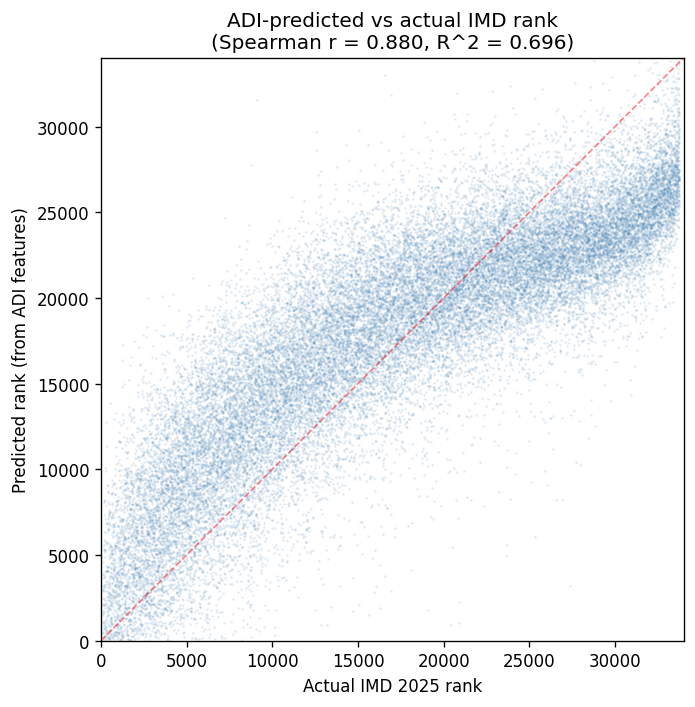

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, y_pred, s=0.3, alpha=0.15, color="steelblue")
ax.plot([0, 34000], [0, 34000], "r--", linewidth=1, alpha=0.5)
ax.set_xlabel("Actual IMD 2025 rank")
ax.set_ylabel("Predicted rank (from ADI features)")
ax.set_title(f"ADI-predicted vs actual IMD rank\n(Spearman r = {r_spearman:.3f}, R^2 = {r2:.3f})")
ax.set_xlim(0, 34000)
ax.set_ylim(0, 34000)
ax.set_aspect("equal")
fig.tight_layout()
plt.savefig(repo_root / "store" / "outputs" / "adi_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpretation

The full ADI model achieves Spearman r = 0.88 with the IMD 2025 rank,
explaining 70% of variance (R^2 = 0.70). This is notable because the ADI
only covers 3 of the IMD's 7 domains — income, education, barriers to
housing, and living environment are absent.

**Claimant rate alone (r = 0.85)** nearly matches the full model,
confirming that employment/income deprivation is the dominant driver of
overall IMD rank. Adding crime and health features provides only marginal
improvement in rank prediction.

**The old ADI formula (r = 0.41)** performs poorly because it sums rates
with vastly different scales. Depression prevalence (~0.09) and mental
health prevalence (~0.009) are dwarfed by crime rates (~0.03 per type x
14 types). A simple sum is not meaningful without normalisation.

**Health features are individually weak but collectively strong** (60% of
model importance). COPD, asthma, cancer, and stroke are the top health
predictors — not depression or mental health. This suggests that chronic
respiratory and cardiovascular disease burden is a better marker of
IMD-like deprivation than mental health diagnosis rates.